In [1]:
!pip install pandas mlxtend


   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 9.1 MB/s eta 0:00:00


In [3]:
print("Number of transactions:", len(transactions))
print("Number of unique SKUs:", df['SKU'].nunique())


NameError: name 'transactions' is not defined

In [7]:
print("Missing SKUs:", df['SKU'].isna().sum())
print("Empty SKUs:", (df['SKU'] == '').sum())


Missing SKUs: 0
Empty SKUs: 0


In [9]:
sku_counts = df.groupby('BILL_NO')['SKU'].count()
print(sku_counts.describe())
print("Transactions with more than 1 SKU:", (sku_counts > 1).sum())
print("Percentage with more than 1 SKU:", (sku_counts > 1).sum() / len(sku_counts) * 100)


count    29872.000000
mean         4.440781
std          3.478208
min          1.000000
25%          2.000000
50%          3.000000
75%          7.000000
max         56.000000
Name: SKU, dtype: float64
Transactions with more than 1 SKU: 24757
Percentage with more than 1 SKU: 82.87694161756829


In [ ]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

FREEBIE_SKUS = [
    'MABOATPB3990', 'MAAIRPODS4999', 'MAPOWBANK3999',
    'MAAIRPODS3599', 'MATROLLEY9999', 'UAGY01BLK699', 'MAKRAFTBAGBIG'
]

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Load your data
df = pd.read_excel("C:\\Users\\MOUNIKA PALLI\\Dropbox\\EBO FOLDER\\EBO SALES FOLDER\\EBO SALES DATA.xlsx")
df['SKU'] = df['SKU'].astype(str)

# Exclude freebie SKUs
df = df[~df['SKU'].isin(FREEBIE_SKUS)].copy()
top_skus = df['SKU'].value_counts().nlargest(1000).index
df = df[df['SKU'].isin(top_skus)]
# Group by bill_no to create transactions (after removing freebies)
transactions = df.groupby('BILL_NO')['SKU'].apply(list)

# Remove transactions with only a single SKU
transactions = transactions[transactions.apply(lambda x: len(x) > 1)].tolist()

# Encode transactions using sparse matrix
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions, sparse=True)
df_encoded = pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)

# Use FP-Growth instead of Apriori, limit to pairs
frequent_itemsets = fpgrowth(df_encoded, min_support=0.0002, use_colnames=True, max_len=2)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.05)

# Show rules and frequent pairs
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])
print(frequent_itemsets[ frequent_itemsets['itemsets'].apply(lambda x: len(x) > 1) ])

# Prepare dataframes for export
rules_export = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
# Convert frozensets to strings for Excel readability
rules_export['antecedents'] = rules_export['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_export['consequents'] = rules_export['consequents'].apply(lambda x: ', '.join(list(x)))

frequent_pairs = frequent_itemsets[ frequent_itemsets['itemsets'].apply(lambda x: len(x) > 1) ].copy()
frequent_pairs['itemsets'] = frequent_pairs['itemsets'].apply(lambda x: ', '.join(list(x)))

# Export to Excel
with pd.ExcelWriter('market_basket_analysis_results.xlsx') as writer:
    rules_export.to_excel(writer, sheet_name='Association Rules', index=False)
    frequent_pairs.to_excel(writer, sheet_name='Frequent Pairs', index=False)

print("Exported results to 'market_basket_analysis_results.xlsx'")



C:\Users\MOUNIKA PALLI\AppData\Local\Temp\ipykernel_20604\550130707.py:30: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  df_encoded = pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)


In [31]:
from itertools import combinations
from collections import Counter

pair_counter = Counter()
for items in transactions:
    if len(items) > 1:
        pairs = combinations(sorted(set(items)), 2)
        pair_counter.update(pairs)

print(pair_counter.most_common(20))  # Top 20 most common pairs


[(('MPOR89BLKLAR', 'MPOR89BTELAR'), 47), (('MPOR89BLKXLR', 'MPOR89BTEXLR'), 43), (('MIOR53BLKLAR', 'MIOR53IRGLAR'), 40), (('MSOR76BLKLAR', 'MSOR76CNGLAR'), 37), (('MTOR10BLKLAR', 'MTOR10WHTLAR'), 35), (('MSOR76BLKXLR', 'MSOR76CNGXLR'), 34), (('MPOR89BTEXLR', 'MPOR89CNGXLR'), 34), (('MIOR53BLKXLR', 'MIOR53IRGXLR'), 34), (('MTOR10BLKXLR', 'MTOR10WHTXLR'), 32), (('MIOR53BLKXLR', 'MIOR53NVYXLR'), 28), (('MPOR89BLKLAR', 'MPOR89NVYLAR'), 27), (('MIOR53BLKLAR', 'MIOR53NVYLAR'), 27), (('MPOR89BLKXLR', 'MPOR89NVYXLR'), 24), (('MPOR89BTEXLR', 'MPOR89NVYXLR'), 23), (('MPP675BLKXLR', 'MPP675BTEXLR'), 23), (('MSOR86BLKXLR', 'MSOR86NVYXLR'), 23), (('MPOR99BLKXLR', 'MPOR99BTEXLR'), 22), (('MSOR76BLKXLR', 'MSOR76LRGXLR'), 22), (('MSOR86BLKXLR', 'MSOR86BTEXLR'), 22), (('MPOR25BLKLAR', 'MPOR25BTELAR'), 22)]


In [51]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

FREEBIE_SKUS = [
    'MABOATPB3990', 'MAAIRPODS4999', 'MAPOWBANK3999',
    'MAAIRPODS3599', 'MATROLLEY9999', 'UAGY01BLK699', 'MAKRAFTBAGBIG'
]

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Load your data
df = pd.read_excel("C:\\Users\\Mounika\\Dropbox\\EBO FOLDER\\EBO SALES FOLDER\\EBO SALES DATA.xlsx")
df['STYLE'] = df['STYLE'].astype(str)

# Exclude freebie SKUs
df = df[~df['SKU'].isin(FREEBIE_SKUS)].copy()
top_skus = df['SKU'].value_counts().nlargest(1000).index
df = df[df['SKU'].isin(top_skus)]
# Group by bill_no to create transactions (after removing freebies)
transactions = df.groupby('BILL_NO')['STYLE'].apply(list)

# Remove transactions with only a single SKU
transactions = transactions[transactions.apply(lambda x: len(x) > 1)].tolist()

# Encode transactions using sparse matrix
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions, sparse=True)
df_encoded = pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)

# Use FP-Growth instead of Apriori, limit to pairs
frequent_itemsets = fpgrowth(df_encoded, min_support=0.0002, use_colnames=True, max_len=2)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.05)

# Show rules and frequent pairs
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])
print(frequent_itemsets[ frequent_itemsets['itemsets'].apply(lambda x: len(x) > 1) ])

# ... (your previous code)

# Prepare dataframes for export
rules_export = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
rules_export['antecedents'] = rules_export['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_export['consequents'] = rules_export['consequents'].apply(lambda x: ', '.join(list(x)))

frequent_pairs = frequent_itemsets[ frequent_itemsets['itemsets'].apply(lambda x: len(x) > 1) ].copy()
frequent_pairs['itemsets'] = frequent_pairs['itemsets'].apply(lambda x: ', '.join(list(x)))

# Deduplicate pair rules
pair_rules = rules_export[
    (rules_export['antecedents'].str.count(',') == 0) &
    (rules_export['consequents'].str.count(',') == 0)
].copy()
pair_rules['pair'] = pair_rules.apply(
    lambda row: tuple(sorted([row['antecedents'], row['consequents']])), axis=1
)
pair_rules = pair_rules.drop_duplicates(subset=['pair'])
pair_rules = pair_rules.drop(columns=['pair'])

# Example thresholds (adjust as needed)
min_support = 0.001
min_confidence = 0.2
min_lift = 1.2

# Filter the pair_rules DataFrame based on all three metrics
filtered_rules = pair_rules[
    (pair_rules['support'] >= min_support) &
    (pair_rules['confidence'] >= min_confidence) &
    (pair_rules['lift'] >= min_lift)
]

# Sort by the metric you care most about (e.g., lift) and take top 25
top_25 = filtered_rules.sort_values(by='lift', ascending=False).head(50)

# Export to Excel
with pd.ExcelWriter('market_basket_analysis_top25_filtered.xlsx') as writer:
    top_25.to_excel(writer, sheet_name='Top 25 Rules', index=False)

print("Exported top 25 filtered rules to 'market_basket_analysis_top25_filtered.xlsx'")



C:\Users\Mounika\AppData\Local\Temp\ipykernel_15120\2860172099.py:30: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  df_encoded = pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)


     antecedents consequents   support  confidence      lift
0         (OR76)      (OR46)  0.014824    0.130560  1.908460
1         (OR46)      (OR76)  0.014824    0.216683  1.908460
2         (OR46)      (OR89)  0.006428    0.093960  0.617461
3         (OR46)      (OR10)  0.015086    0.220518  1.153745
4         (OR10)      (OR46)  0.015086    0.078929  1.153745
...          ...         ...       ...         ...       ...
1220      (A201)      (OR10)  0.000328    0.138889  0.726664
1221      (A201)      (OR99)  0.000262    0.111111  0.984884
1222      (A201)      (OR89)  0.000262    0.111111  0.730172
1223      (A201)      (OR25)  0.000328    0.138889  1.167310
1224      (A201)      (W142)  0.000328    0.138889  5.307018

[1225 rows x 5 columns]
       support      itemsets
86    0.014824  (OR76, OR46)
87    0.006428  (OR46, OR89)
88    0.015086  (OR46, OR10)
89    0.004263  (OR53, OR46)
90    0.006166  (OR46, OR60)
...        ...           ...
1814  0.000328  (A201, OR10)
1815  0.000

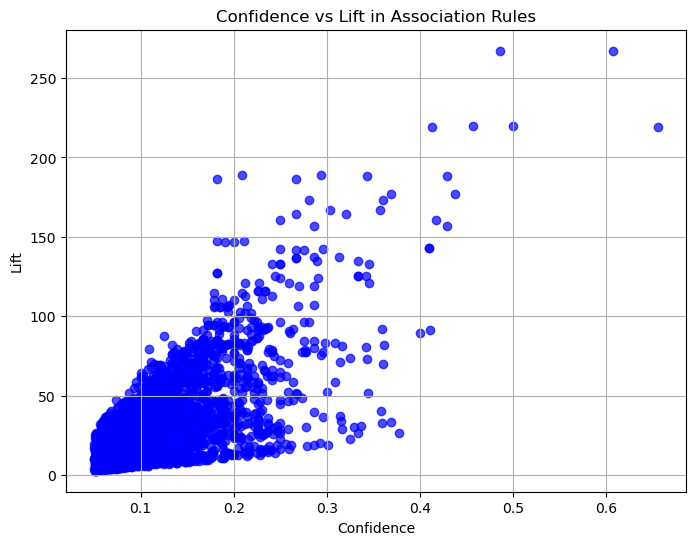

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(rules['confidence'], rules['lift'], alpha=0.7, color='b')
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.title('Confidence vs Lift in Association Rules')
plt.grid()
plt.show()
